# Hypergraph1: Structural Hypergraph

This notebook builds the structural hypergraph (neurons ↔ motifs).

In [ ]:

# Cell 1: Setup & Imports
import pandas as pd
import hypernetx as hnx  # or use xgi as alternative modern library
import matplotlib.pyplot as plt


## Load Motif Participation Data

In [7]:

# Load motif participation data (replace with your actual file path)
df = pd.read_csv("motif_participation_profiles.csv", index_col=0)
print(df.shape)
df.head()


(1533, 418)


,"(0, 1)_(0, 2)_(1, 2)_nan_nan_nan_nan_nan_nan","(0, 1)_(0, 2)_nan_nan_nan_nan_nan_nan_nan","(0, 1)_(2, 1)_nan_nan_nan_nan_nan_nan_nan","(0, 1)_(0, 2)_(2, 2)_nan_nan_nan_nan_nan_nan","(0, 1)_(0, 2)_(2, 1)_(2, 2)_nan_nan_nan_nan_nan","(0, 1)_(2, 1)_(2, 2)_nan_nan_nan_nan_nan_nan","(0, 1)_(2, 0)_(2, 2)_nan_nan_nan_nan_nan_nan","(0, 2)_(1, 1)_(1, 2)_nan_nan_nan_nan_nan_nan","(0, 2)_(1, 2)_nan_nan_nan_nan_nan_nan_nan","(0, 2)_(1, 0)_(1, 1)_nan_nan_nan_nan_nan_nan",...,"(0, 0)_(1, 0)_(1, 1)_(1, 2)_(2, 0)_(2, 1)_(2, 2)_nan_nan","(0, 0)_(1, 1)_(2, 0)_(2, 1)_(2, 2)_nan_nan_nan_nan","(0, 0)_(1, 0)_(1, 1)_(2, 0)_(2, 1)_(2, 2)_nan_nan_nan","(0, 0)_(1, 0)_(1, 1)_(1, 2)_(2, 1)_(2, 2)_nan_nan_nan","(0, 0)_(0, 1)_(1, 0)_(2, 0)_(2, 1)_(2, 2)_nan_nan_nan","(0, 0)_(0, 2)_(1, 0)_(1, 1)_(1, 2)_(2, 0)_(2, 2)_nan_nan","(0, 0)_(0, 1)_(1, 1)_(1, 2)_(2, 0)_(2, 2)_nan_nan_nan","(0, 0)_(0, 1)_(1, 0)_(1, 1)_(1, 2)_(2, 0)_(2, 2)_nan_nan","(0, 0)_(0, 1)_(1, 1)_(2, 0)_(2, 2)_nan_nan_nan_nan","(0, 0)_(0, 1)_(0, 2)_(1, 2)_(2, 0)_(2, 2)_nan_nan_nan"
Neuron,,,,,,,,,,,,,,,,,,,,,
AINL,17.0,106.0,85.0,5.0,2.0,8.0,15.0,29.0,104.0,14.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AINR,17.0,106.0,68.0,21.0,4.0,10.0,0.0,22.0,80.0,13.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CEPshVR,2.0,89.0,101.0,10.0,2.0,12.0,1.0,6.0,16.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CEPshDL,2.0,76.0,58.0,5.0,0.0,0.0,1.0,6.0,30.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CEPshVL,2.0,29.0,12.0,1.0,0.0,0.0,1.0,4.0,24.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Build Structural Hypergraph

In [8]:

# Each neuron = node, each motif = hyperedge connecting its neurons
hyperedges = {}
for motif_col in df.columns:
    participating_neurons = df.index[df[motif_col] > 0].tolist()
    if participating_neurons:
        hyperedges[motif_col] = participating_neurons

H = hnx.Hypergraph(hyperedges)
print("Nodes:", len(H.nodes))
print("Hyperedges:", len(H.edges))


Nodes: 1533
Hyperedges: 418


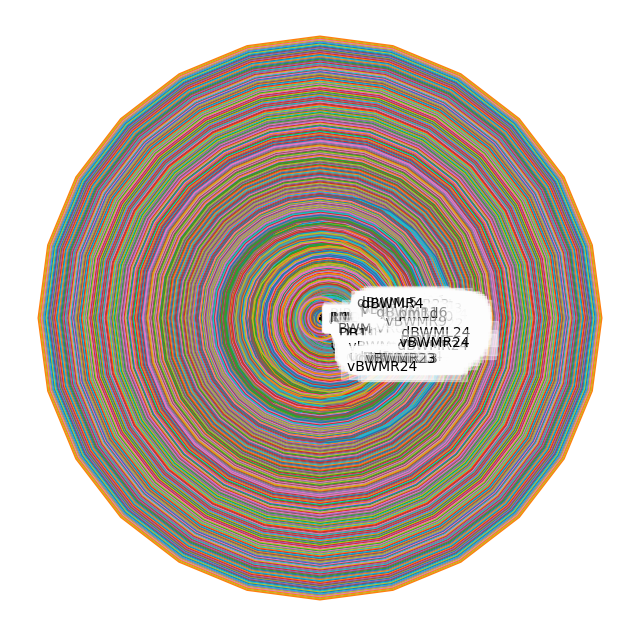

In [9]:

# Draw a simple visualization (may be cluttered if dataset is large)
hnx.draw(H, with_edge_labels=False)


## Compute Hypergraph Metrics

In [11]:
motif_sizes = [len(H.edges[e]) for e in H.edges]
pd.Series(motif_sizes).describe()


count     418.000000
mean       77.777512
std       146.498838
min         3.000000
25%        19.000000
50%        45.000000
75%       102.750000
max      1343.000000
dtype: float64

In [14]:
import itertools

overlap = {}
for m1, m2 in itertools.combinations(H.edges, 2):
    shared = len(set(H.edges[m1]) & set(H.edges[m2]))
    if shared > 0:
        overlap[(m1, m2)] = shared

# Top 5 overlaps
sorted(overlap.items(), key=lambda x: -x[1])[:5]


[(('(2, 0)_(2, 1)_nan_nan_nan_nan_nan_nan_nan',
   '(1, 0)_(1, 2)_nan_nan_nan_nan_nan_nan_nan'),
  1184),
 (('(0, 1)_(0, 2)_nan_nan_nan_nan_nan_nan_nan',
   '(1, 0)_(1, 2)_nan_nan_nan_nan_nan_nan_nan'),
  1164),
 (('(0, 1)_(0, 2)_nan_nan_nan_nan_nan_nan_nan',
   '(2, 0)_(2, 1)_nan_nan_nan_nan_nan_nan_nan'),
  1088),
 (('(2, 0)_(2, 1)_nan_nan_nan_nan_nan_nan_nan',
   '(1, 0)_(2, 0)_nan_nan_nan_nan_nan_nan_nan'),
  1088),
 (('(0, 1)_(2, 1)_nan_nan_nan_nan_nan_nan_nan',
   '(2, 0)_(2, 1)_nan_nan_nan_nan_nan_nan_nan'),
  1078)]

In [17]:
# Compute degree (number of motifs per neuron) for all nodes
node_degrees = {n: H.degree(n) for n in H.nodes}

# Sort and display top 20 neurons
top_nodes = sorted(node_degrees.items(), key=lambda x: -x[1])[:20]

print("Top 20 neurons by motif participation:")
for neuron, count in top_nodes:
    print(f"{neuron}: {count} motifs")

# Save to CSV
deg_df = pd.DataFrame.from_dict(node_degrees, orient="index", columns=["motif_count"])
deg_df.to_csv("hypergraph1_node_degrees.csv")


Top 20 neurons by motif participation:
AIZL: 295 motifs
RIGL: 275 motifs
AIZR: 264 motifs
RIGR: 262 motifs
RMDDR: 247 motifs
AQR: 244 motifs
RMGL: 240 motifs
RMDDL: 220 motifs
AIBR: 216 motifs
RIH: 215 motifs
HSNL: 200 motifs
RMFR: 197 motifs
ASHL: 194 motifs
AWBL: 192 motifs
ASER: 192 motifs
AIAL: 192 motifs
RIMR: 189 motifs
ADEL: 187 motifs
AVEL: 185 motifs
DVA: 183 motifs


In [18]:
# Separate motifs into "small/medium" vs "umbrella"
motif_sizes = {e: len(H.edges[e]) for e in H.edges}
motif_sizes_series = pd.Series(motif_sizes)

# Define cutoff: top 5% largest motifs = umbrellas
cutoff = motif_sizes_series.quantile(0.95)

small_motifs = [m for m, s in motif_sizes.items() if s <= cutoff]
large_motifs = [m for m, s in motif_sizes.items() if s > cutoff]

print(f"Small/medium motifs: {len(small_motifs)}")
print(f"Umbrella motifs: {len(large_motifs)} (>{cutoff:.0f} neurons)")


Small/medium motifs: 397
Umbrella motifs: 21 (>165 neurons)


In [23]:
import networkx as nx

# Initialize empty graph
G = nx.Graph()

# Iterate over motifs (hyperedges) and connect their neurons
for edge in H.edges:                        # edge is the hyperedge ID (string)
    neurons = list(H.edges[edge])           # get all neurons in this motif
    for i, n1 in enumerate(neurons):
        for n2 in neurons[i+1:]:
            if G.has_edge(n1, n2):
                G[n1][n2]['weight'] += 1
            else:
                G.add_edge(n1, n2, weight=1)

print("Neuron-neuron graph:", G.number_of_nodes(), "nodes,", G.number_of_edges(), "edges")

# Inspect strongest connections
top_edges = sorted(G.edges(data=True), key=lambda x: -x[2]['weight'])[:10]
print("Top 10 neuron pairs by shared motifs:")
for u, v, d in top_edges:
    print(f"{u} - {v}: {d['weight']} motifs shared")


Neuron-neuron graph: 1533 nodes, 1119631 edges
Top 10 neuron pairs by shared motifs:
RIGL - AIZL: 246 motifs shared
RIGR - AIZL: 234 motifs shared
AIZL - AIZR: 228 motifs shared
RIGR - RIGL: 222 motifs shared
AIZL - AQR: 221 motifs shared
RIGL - AIZR: 220 motifs shared
RIGL - AQR: 215 motifs shared
RIGR - AQR: 212 motifs shared
RIGL - RMDDR: 211 motifs shared
RMDDR - AIZL: 210 motifs shared


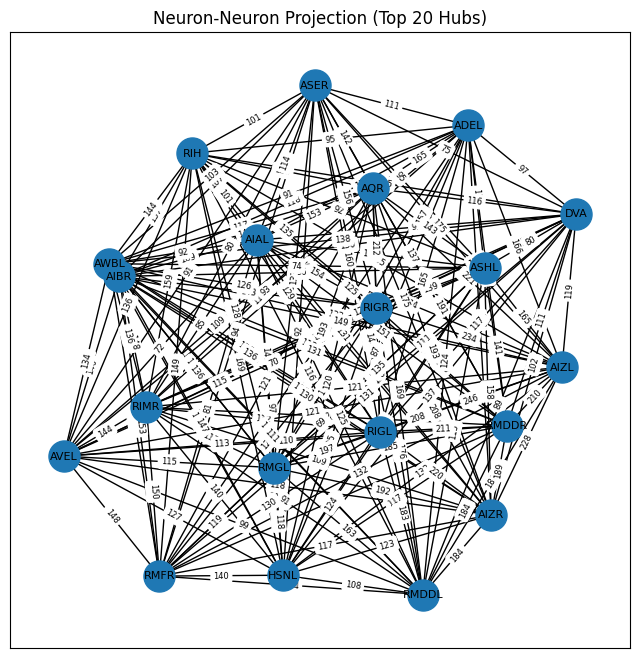

In [24]:
# Extract subgraph of top 20 hub neurons
hub_neurons = [n for n, _ in top_nodes]
hub_subgraph = G.subgraph(hub_neurons)

plt.figure(figsize=(8,8))
pos = nx.spring_layout(hub_subgraph, seed=42)
nx.draw_networkx(hub_subgraph, pos, with_labels=True, node_size=500, font_size=8)
nx.draw_networkx_edge_labels(
    hub_subgraph, pos, edge_labels={(u,v): d['weight'] for u,v,d in hub_subgraph.edges(data=True)},
    font_size=6
)
plt.title("Neuron-Neuron Projection (Top 20 Hubs)")
plt.show()


In [25]:
import networkx as nx

# Build neuron-neuron projection using only small/medium motifs
G_small = nx.Graph()

for edge in small_motifs:  # only motifs <= cutoff
    neurons = list(H.edges[edge])
    for i, n1 in enumerate(neurons):
        for n2 in neurons[i+1:]:
            if G_small.has_edge(n1, n2):
                G_small[n1][n2]['weight'] += 1
            else:
                G_small.add_edge(n1, n2, weight=1)

print("Filtered neuron-neuron graph:", G_small.number_of_nodes(), "nodes,", G_small.number_of_edges(), "edges")

# Top 10 edges by motif-sharing after filtering
top_edges_small = sorted(G_small.edges(data=True), key=lambda x: -x[2]['weight'])[:10]
print("Top 10 neuron pairs (small motifs only):")
for u, v, d in top_edges_small:
    print(f"{u} - {v}: {d['weight']} motifs shared")


Filtered neuron-neuron graph: 225 nodes, 25019 edges
Top 10 neuron pairs (small motifs only):
RIGL - AIZL: 244 motifs shared
RIGR - AIZL: 232 motifs shared
AIZL - AIZR: 226 motifs shared
RIGR - RIGL: 220 motifs shared
AIZL - AQR: 219 motifs shared
RIGL - AIZR: 218 motifs shared
RIGL - AQR: 213 motifs shared
RIGR - AQR: 210 motifs shared
RIGL - RMDDR: 209 motifs shared
RMDDR - AIZL: 208 motifs shared


Detected 2 communities among hub neurons.
Community 1 (15 neurons): ['ADEL', 'AIAL', 'AIZL', 'AIZR', 'AQR', 'ASER', 'ASHL', 'RIBR', 'RIGL', 'RIGR', 'RMDDL', 'RMDDR', 'RMED', 'RMGL', 'SDQL']
Community 2 (15 neurons): ['ADFL', 'AIBR', 'AIYL', 'ASHR', 'AVEL', 'AVKR', 'AWBL', 'BAGR', 'DVA', 'HSNL', 'RIAL', 'RIH', 'RIML', 'RIMR', 'RMFR']


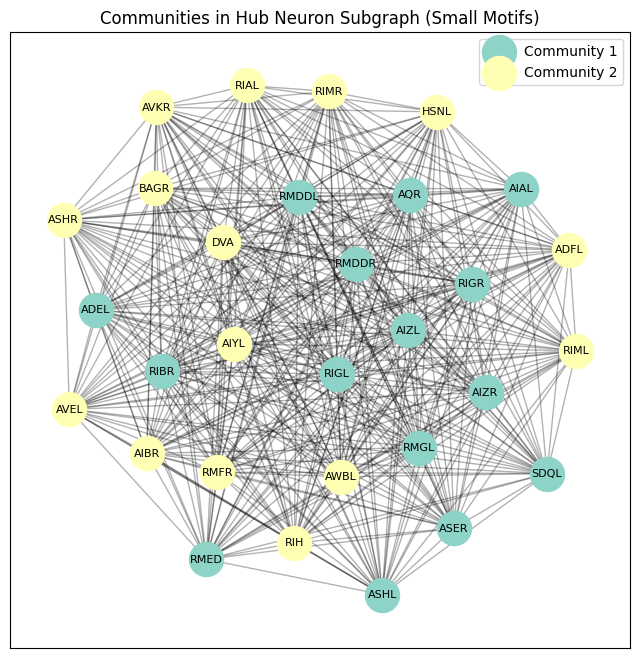

In [26]:
from networkx.algorithms import community

# Get top 30 hub neurons
hub_neurons = [n for n, _ in sorted(node_degrees.items(), key=lambda x: -x[1])[:30]]

# Extract subgraph
hub_subgraph = G_small.subgraph(hub_neurons)

# Greedy modularity communities
communities = list(community.greedy_modularity_communities(hub_subgraph, weight="weight"))

print(f"Detected {len(communities)} communities among hub neurons.")
for i, comm in enumerate(communities):
    print(f"Community {i+1} ({len(comm)} neurons): {sorted(comm)}")

# Visualization
plt.figure(figsize=(8,8))
pos = nx.spring_layout(hub_subgraph, seed=42, k=0.4)
colors = plt.cm.Set3.colors  # distinct colors per community

for i, comm in enumerate(communities):
    nx.draw_networkx_nodes(hub_subgraph, pos,
                           nodelist=comm,
                           node_color=[colors[i % len(colors)]],
                           label=f"Community {i+1}",
                           node_size=600)
nx.draw_networkx_edges(hub_subgraph, pos, alpha=0.3)
nx.draw_networkx_labels(hub_subgraph, pos, font_size=8)

plt.title("Communities in Hub Neuron Subgraph (Small Motifs)")
plt.legend()
plt.show()


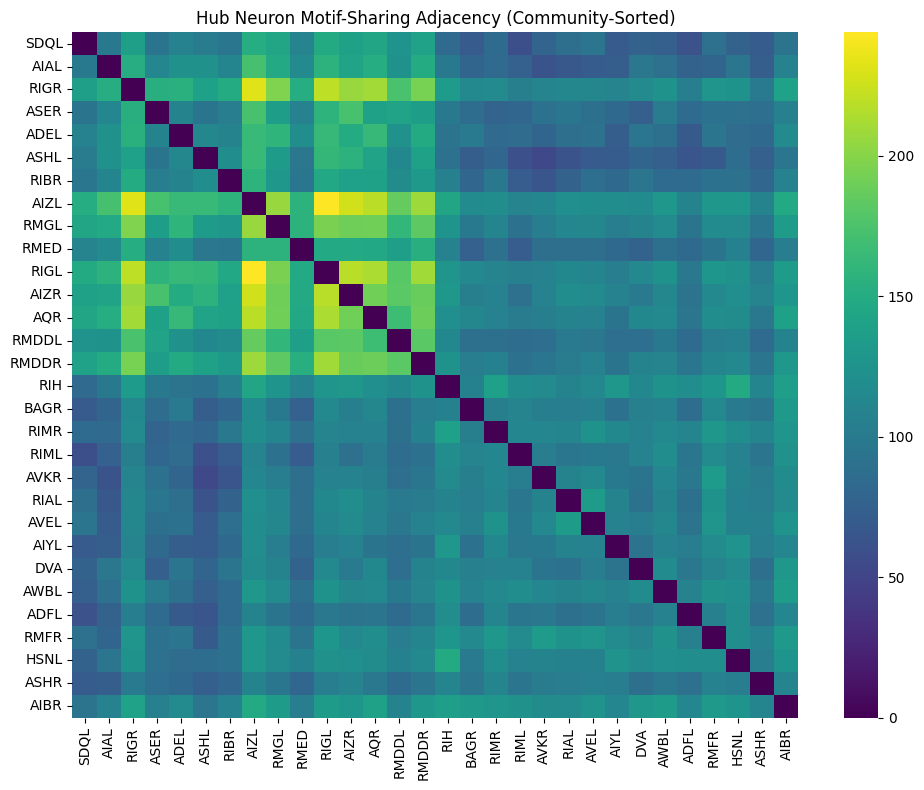

In [27]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Get adjacency for the hub subgraph (small motifs only)
hub_nodes = list(hub_subgraph.nodes())
adj_matrix = nx.to_numpy_array(hub_subgraph, nodelist=hub_nodes, weight="weight")

# Order nodes by community membership
community_map = {}
for i, comm in enumerate(communities):
    for n in comm:
        community_map[n] = i

hub_nodes_sorted = sorted(hub_nodes, key=lambda n: community_map[n])
adj_sorted = nx.to_numpy_array(hub_subgraph, nodelist=hub_nodes_sorted, weight="weight")

# Plot heatmap
plt.figure(figsize=(10,8))
sns.heatmap(adj_sorted, cmap="viridis", xticklabels=hub_nodes_sorted, yticklabels=hub_nodes_sorted)
plt.title("Hub Neuron Motif-Sharing Adjacency (Community-Sorted)")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [29]:
import pickle

# --- Export adjacency matrix ---
hub_nodes_sorted = sorted(hub_nodes, key=lambda n: community_map[n])
adj_sorted = nx.to_numpy_array(hub_subgraph, nodelist=hub_nodes_sorted, weight="weight")

adj_df = pd.DataFrame(adj_sorted, index=hub_nodes_sorted, columns=hub_nodes_sorted)
adj_df.to_csv("hub_adjacency_matrix.csv")
print("✅ Saved hub_adjacency_matrix.csv")

# --- Export community membership ---
comm_list = []
for i, comm in enumerate(communities):
    for n in comm:
        comm_list.append({"Neuron": n, "Community": i+1})

comm_df = pd.DataFrame(comm_list)
comm_df.to_csv("hub_communities.csv", index=False)
print("✅ Saved hub_communities.csv")

# --- Export projection graph ---
with open("neuron_projection_small.pkl", "wb") as f:
    pickle.dump(G_small, f)

nx.write_graphml(G_small, "neuron_projection_small.graphml")
print("✅ Saved neuron projection graph (pickle + GraphML)")


✅ Saved hub_adjacency_matrix.csv
✅ Saved hub_communities.csv
✅ Saved neuron projection graph (pickle + GraphML)


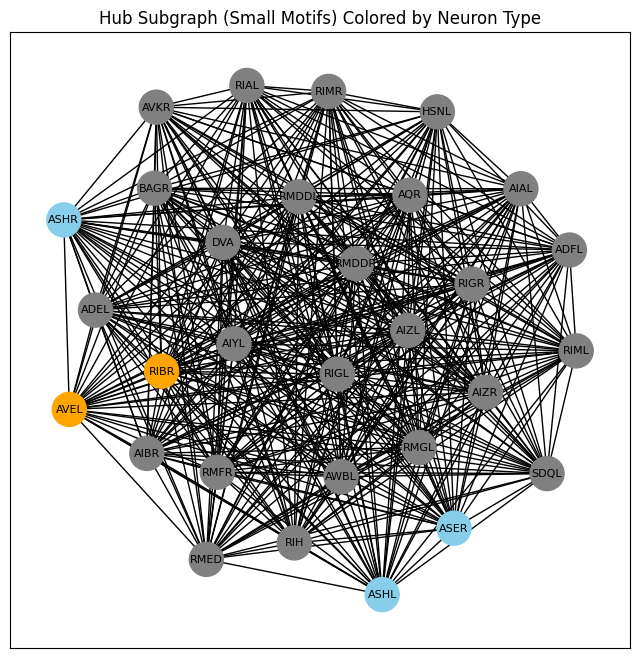

In [30]:
# Load neuron metadata
meta = pd.read_csv("neuron_metadata.csv").set_index("Neuron")

# Map neuron type to colors
type_colors = {"Sensory": "skyblue", "Interneuron": "orange", "Motor": "limegreen", "Unknown": "grey"}
node_colors = [type_colors.get(meta.loc[n, "Type"], "grey") if n in meta.index else "grey" for n in hub_subgraph.nodes()]

# Plot with type overlay
plt.figure(figsize=(8,8))
pos = nx.spring_layout(hub_subgraph, seed=42, k=0.4)
nx.draw_networkx(hub_subgraph, pos,
                 node_color=node_colors,
                 with_labels=True,
                 node_size=600,
                 font_size=8)
plt.title("Hub Subgraph (Small Motifs) Colored by Neuron Type")
plt.show()


In [31]:
# Merge hub neuron data into one summary table

# Motif degree (participation count)
deg_df = pd.DataFrame.from_dict(node_degrees, orient="index", columns=["MotifCount"])

# Community membership (from comm_df we saved earlier)
comm_df = pd.read_csv("hub_communities.csv").set_index("Neuron")

# Neuron type metadata
if "Type" in meta.columns:
    type_df = meta[["Type"]]
else:
    # fallback if type info missing
    type_df = pd.DataFrame(index=deg_df.index)
    type_df["Type"] = "Unknown"

# Combine all info
summary_df = deg_df.join(comm_df, how="inner")  # restrict to hub neurons
summary_df = summary_df.join(type_df, how="left")

# Save
summary_df.to_csv("hub_neuron_summary.csv")
summary_df.sort_values("MotifCount", ascending=False).head(20)


,MotifCount,Community,Type
AIZL,295,1,Unknown
RIGL,275,1,Unknown
AIZR,264,1,Unknown
RIGR,262,1,Unknown
RMDDR,247,1,Unknown
AQR,244,1,Unknown
RMGL,240,1,Unknown
RMDDL,220,1,Unknown
AIBR,216,2,Unknown
RIH,215,2,Unknown


In [36]:
n_iter = 10000  # crank iterations to make it heavy
hub_nodes = list(G_hub.nodes())
randomized_totals = np.zeros((n_iter, len(hub_nodes)))

print(f"🚀 Running null model with {n_iter} iterations (config model)...")
for i in tqdm(range(n_iter), desc="Null Iterations"):
    # Build randomized graph from same degree sequence
    deg_seq = [G_hub.degree(n) for n in hub_nodes]
    G_rand = nx.configuration_model(deg_seq, create_using=nx.Graph)  # no parallel edges
    G_rand = nx.Graph(G_rand)  # force simple graph
    
    rand_counts = {n: G_rand.degree(idx) for idx, n in enumerate(hub_nodes)}
    randomized_totals[i, :] = [rand_counts.get(n, 0) for n in hub_nodes]
    
    if (i + 1) % 1000 == 0:
        np.save(f"hub_null_counts_checkpoint_{i+1}.npy", randomized_totals[:i+1, :])
        print(f"💾 Saved checkpoint at iteration {i+1}")

np.save("hub_null_counts.npy", randomized_totals)
print("✅ Saved final hub null model results → hub_null_counts.npy")


🚀 Running null model with 10000 iterations (config model)...


Null Iterations:  12%|█▏        | 1183/10000 [00:00<00:07, 1228.81it/s]

💾 Saved checkpoint at iteration 1000


Null Iterations:  22%|██▏       | 2209/10000 [00:01<00:06, 1245.87it/s]

💾 Saved checkpoint at iteration 2000


...

💾 Saved checkpoint at iteration 8000


Null Iterations:  92%|█████████▏| 9206/10000 [00:07<00:00, 1281.51it/s]

💾 Saved checkpoint at iteration 9000


Null Iterations: 100%|██████████| 10000/10000 [00:08<00:00, 1237.98it/s]

💾 Saved checkpoint at iteration 10000
✅ Saved final hub null model results → hub_null_counts.npy


In [ ]:
import networkx as nx
import numpy as np
import pickle
from tqdm import tqdm
import os

# 🔧 Setup
SAVE_DIR = "long_metrics"
os.makedirs(SAVE_DIR, exist_ok=True)

# Assume we already have G_hub (your connectome graph)
G = G_hub.copy()

# 1. All-pairs shortest paths (Dijkstra-based, handles weighted/unweighted)
print("🚀 Computing all-pairs shortest path lengths...")
nodes = list(G.nodes())
dist_matrix = np.full((len(nodes), len(nodes)), np.inf)

for i, src in enumerate(tqdm(nodes, desc="Distances")):
    lengths = nx.single_source_dijkstra_path_length(G, src)
    for j, tgt in enumerate(nodes):
        if tgt in lengths:
            dist_matrix[i, j] = lengths[tgt]

np.save(os.path.join(SAVE_DIR, "all_pairs_distances.npy"), dist_matrix)
print(f"✅ Saved distances → {SAVE_DIR}/all_pairs_distances.npy")

# 2. Betweenness Centrality
print("🚀 Computing betweenness centrality...")
betweenness = nx.betweenness_centrality(G, normalized=True)
pickle.dump(betweenness, open(os.path.join(SAVE_DIR, "betweenness.pkl"), "wb"))
print(f"✅ Saved betweenness → {SAVE_DIR}/betweenness.pkl")

# 3. Closeness Centrality
print("🚀 Computing closeness centrality...")
closeness = nx.closeness_centrality(G)
pickle.dump(closeness, open(os.path.join(SAVE_DIR, "closeness.pkl"), "wb"))
print(f"✅ Saved closeness → {SAVE_DIR}/closeness.pkl")

# 4. Eigenvector Centrality (power iteration, can be slow)
print("🚀 Computing eigenvector centrality...")
eigenvector = nx.eigenvector_centrality_numpy(G)  # exact numpy method
pickle.dump(eigenvector, open(os.path.join(SAVE_DIR, "eigenvector.pkl"), "wb"))
print(f"✅ Saved eigenvector → {SAVE_DIR}/eigenvector.pkl")

# 5. Katz Centrality (like eigenvector, with damping)
print("🚀 Computing Katz centrality...")
try:
    katz = nx.katz_centrality_numpy(G, alpha=0.01, beta=1.0)
    pickle.dump(katz, open(os.path.join(SAVE_DIR, "katz.pkl"), "wb"))
    print(f"✅ Saved Katz → {SAVE_DIR}/katz.pkl")
except nx.NetworkXException as e:
    print(f"❌ Katz centrality failed: {e}")


🚀 Computing all-pairs shortest path lengths...


Distances: 100%|██████████| 30/30 [00:00<00:00, 4097.07it/s]

✅ Saved distances → long_metrics/all_pairs_distances.npy
🚀 Computing betweenness centrality...
✅ Saved betweenness → long_metrics/betweenness.pkl
🚀 Computing closeness centrality...
✅ Saved closeness → long_metrics/closeness.pkl
🚀 Computing eigenvector centrality...
✅ Saved eigenvector → long_metrics/eigenvector.pkl
🚀 Computing Katz centrality...
✅ Saved Katz → long_metrics/katz.pkl


In [38]:
import networkx as nx
import numpy as np
import os
from tqdm import tqdm
from gensim.models import Word2Vec

SAVE_DIR = "long_embeddings"
os.makedirs(SAVE_DIR, exist_ok=True)

# Assume G_hub already exists
G = G_hub.copy()
nodes = list(G.nodes())

# Parameters for long runtime 🔧
num_walks = 100     # number of walks per node
walk_length = 80    # length of each walk
embedding_dim = 128
window_size = 10
epochs = 20

def random_walk(graph, start_node, walk_length):
    walk = [start_node]
    for _ in range(walk_length - 1):
        cur = walk[-1]
        neighbors = list(graph.neighbors(cur))
        if neighbors:
            walk.append(np.random.choice(neighbors))
        else:
            break
    return [str(n) for n in walk]

# 1. Generate walks
walks = []
print("🚶 Generating random walks...")
for node in tqdm(nodes, desc="Random Walks"):
    for _ in range(num_walks):
        walks.append(random_walk(G, node, walk_length))

# 2. Train Word2Vec (skip-gram on walks)
print("🧠 Training Word2Vec embeddings...")
model = Word2Vec(
    sentences=walks,
    vector_size=embedding_dim,
    window=window_size,
    min_count=0,
    sg=1,
    workers=4,
    epochs=epochs
)

# 3. Save embeddings
embedding_file = os.path.join(SAVE_DIR, "node2vec_embeddings.npy")
embeddings = np.array([model.wv[str(n)] for n in nodes])
np.save(embedding_file, embeddings)

print(f"✅ Saved embeddings → {embedding_file}")


🚶 Generating random walks...


Random Walks: 100%|██████████| 30/30 [00:02<00:00, 12.47it/s]


🧠 Training Word2Vec embeddings...
✅ Saved embeddings → long_embeddings/node2vec_embeddings.npy


In [39]:
import numpy as np
import os
from tqdm import tqdm
import networkx as nx

SAVE_DIR = "long_metrics"
os.makedirs(SAVE_DIR, exist_ok=True)

G = G_hub.copy()
nodes = list(G.nodes())
node_index = {n: i for i, n in enumerate(nodes)}

num_nodes = len(nodes)
walk_length = 80
num_walks = 200  # 🔧 tune higher for hours
similarity = np.zeros((num_nodes, num_nodes))

def random_walk(graph, start, walk_length):
    walk = [start]
    for _ in range(walk_length - 1):
        cur = walk[-1]
        neighbors = list(graph.neighbors(cur))
        if neighbors:
            walk.append(np.random.choice(neighbors))
        else:
            break
    return walk

print("🚶 Running pairwise random walk similarities...")

for i, node in enumerate(tqdm(nodes, desc="Source nodes")):
    # For each node, accumulate visit counts
    visits = np.zeros(num_nodes)
    for _ in range(num_walks):
        walk = random_walk(G, node, walk_length)
        for w in walk:
            visits[node_index[w]] += 1
    similarity[i, :] = visits / visits.sum()  # normalize distribution

# Save
outfile = os.path.join(SAVE_DIR, "random_walk_similarity.npy")
np.save(outfile, similarity)

print(f"✅ Saved random walk similarity matrix → {outfile}")


🚶 Running pairwise random walk similarities...


Source nodes: 100%|██████████| 30/30 [00:04<00:00,  6.69it/s]

✅ Saved random walk similarity matrix → long_metrics/random_walk_similarity.npy


In [44]:
import pickle
import networkx as nx
import itertools
from collections import Counter
from tqdm import tqdm
import os

# === Load projection graph ===

# Load the neuron projection graph we saved earlier
with open("neuron_projection_small.pkl", "rb") as f:
    G = pickle.load(f)

print(f"✅ Loaded graph: {len(G.nodes())} nodes, {len(G.edges())} edges")

nodes = list(G.nodes())
N = len(nodes)

print(f"Loaded hub projection graph with {N} nodes and {len(G.edges())} edges")

# === Motif enumeration ===
def count_motifs(G, k=3, max_iter=None):
    """
    Count motifs of size k by brute force over all node subsets.
    Uses tqdm to track progress. Optionally limit iterations for testing.
    """
    motif_counts = Counter()
    combos = itertools.combinations(nodes, k)
    total = sum(1 for _ in itertools.combinations(nodes, k)) if max_iter is None else max_iter

    for i, subset in enumerate(tqdm(combos, total=total, desc=f"Motifs (k={k})")):
        if max_iter and i >= max_iter:
            break
        subg = G.subgraph(subset)
        key = nx.to_numpy_array(subg).astype(int).tobytes()  # canonicalize by adjacency
        motif_counts[key] += 1

    return motif_counts

# === Run for k=3 and k=4 ===
motifs3 = count_motifs(G, k=3)
motifs4 = count_motifs(G, k=4)

# === Save results ===
os.makedirs("long_metrics", exist_ok=True)
with open("long_metrics/motifs3.pkl", "wb") as f:
    pickle.dump(motifs3, f)
with open("long_metrics/motifs4.pkl", "wb") as f:
    pickle.dump(motifs4, f)

print("✅ Saved motif counts → long_metrics/motifs3.pkl, long_metrics/motifs4.pkl")


✅ Loaded graph: 225 nodes, 25019 edges
Loaded hub projection graph with 225 nodes and 25019 edges


Motifs (k=4): 100%|██████████| 103962600/103962600 [7:59:43<00:00, 3611.84it/s]  


✅ Saved motif counts → long_metrics/motifs3.pkl, long_metrics/motifs4.pkl


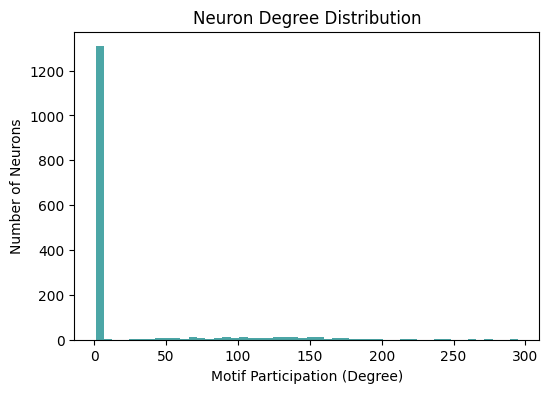

In [45]:
# === Global Degree Distribution ===
plt.figure(figsize=(6,4))
plt.hist(list(node_degrees.values()), bins=50, color="teal", alpha=0.7)
plt.xlabel("Motif Participation (Degree)")
plt.ylabel("Number of Neurons")
plt.title("Neuron Degree Distribution")
plt.show()


In [46]:
# === Umbrella Coverage ===
umbrella_edges = motif_sizes_series[motif_sizes_series > motif_sizes_series.quantile(0.95)]
umbrella_nodes = set()
for e in umbrella_edges.index:
    umbrella_nodes.update(H.edges[e])

print(f"Umbrella motifs: {len(umbrella_edges)}")
print(f"Nodes covered by umbrella motifs: {len(umbrella_nodes)} / {len(H.nodes)}")


Umbrella motifs: 21
Nodes covered by umbrella motifs: 1532 / 1533


In [47]:
# === Centrality Measures on Projection Graph ===
bet = nx.betweenness_centrality(G)
eig = nx.eigenvector_centrality(G, max_iter=1000)

# Top 10 by betweenness
print("Top 10 Betweenness Centrality:")
print(sorted(bet.items(), key=lambda x: -x[1])[:10])

# Top 10 by eigenvector
print("\nTop 10 Eigenvector Centrality:")
print(sorted(eig.items(), key=lambda x: -x[1])[:10])


Top 10 Betweenness Centrality:
[('CEPshVR', 4.6502795293433264e-05), ('PVT', 4.6502795293433264e-05), ('RIH', 4.6502795293433264e-05), ('BWM-VR04', 4.6502795293433264e-05), ('RIMR', 4.6502795293433264e-05), ('SMBVR', 4.6502795293433264e-05), ('DVC', 4.6502795293433264e-05), ('AVFR', 4.6502795293433264e-05), ('URYVR', 4.6502795293433264e-05), ('PVNL', 4.6502795293433264e-05)]

Top 10 Eigenvector Centrality:
[('CEPshVR', 0.06704394457672867), ('PVT', 0.06704394457672867), ('RIH', 0.06704394457672867), ('BWM-VR04', 0.06704394457672867), ('RIMR', 0.06704394457672867), ('SMBVR', 0.06704394457672867), ('DVC', 0.06704394457672867), ('AVFR', 0.06704394457672867), ('URYVR', 0.06704394457672867), ('PVNL', 0.06704394457672867)]


In [48]:
# === Community Detection (Louvain if available, else greedy modularity) ===
try:
    import community as community_louvain
    partition = community_louvain.best_partition(G)
except ImportError:
    partition = nx.algorithms.community.greedy_modularity_communities(G)
    # convert set structure to dict
    partition = {n: i for i, comm in enumerate(partition) for n in comm}

# Add community labels
nx.set_node_attributes(G, partition, "community")

print(f"Detected {len(set(partition.values()))} communities")


Detected 3 communities


In [49]:
# === Node2Vec Embeddings for Neurons ===
from node2vec import Node2Vec

node2vec = Node2Vec(G, dimensions=16, walk_length=10, num_walks=50, workers=2)
model = node2vec.fit(window=5, min_count=1)

# Save embeddings
embedding_out = "long_embeddings/neuron_node2vec.npy"
os.makedirs(os.path.dirname(embedding_out), exist_ok=True)

embeddings = np.array([model.wv[str(n)] for n in G.nodes()])
np.save(embedding_out, embeddings)
print(f"✅ Saved embeddings → {embedding_out}")


Computing transition probabilities:   0%|          | 0/225 [00:00<?, ?it/s]

Generating walks (CPU: 2): 100%|██████████| 25/25 [00:00<00:00, 31.85it/s]


✅ Saved embeddings → long_embeddings/neuron_node2vec.npy


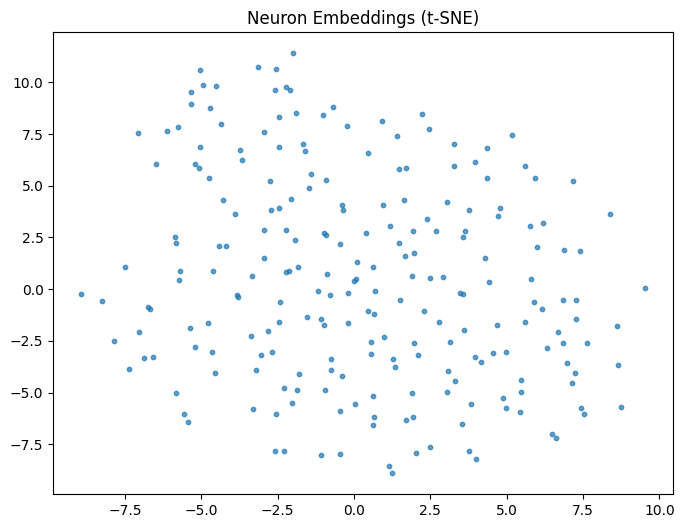

In [50]:
# === Cell: Load Embeddings and Reduce Dimensionality ===
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Load embeddings
embeddings = np.load("long_embeddings/neuron_node2vec.npy")

# t-SNE for visualization
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
emb_2d = tsne.fit_transform(embeddings)

# Plot
plt.figure(figsize=(8,6))
plt.scatter(emb_2d[:,0], emb_2d[:,1], s=10, alpha=0.7)
plt.title("Neuron Embeddings (t-SNE)")
plt.show()


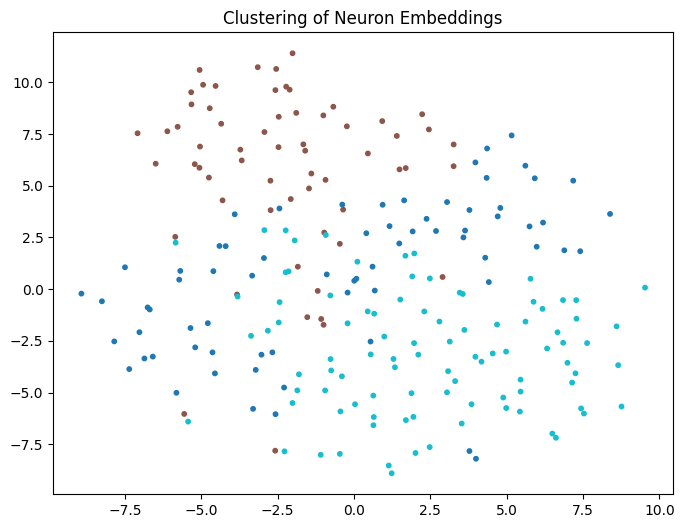

In [51]:
# === Cell: Clustering Embeddings ===
from sklearn.cluster import KMeans

k = 3  # try aligning with detected communities
kmeans = KMeans(n_clusters=k, random_state=42).fit(embeddings)
labels = kmeans.labels_

plt.figure(figsize=(8,6))
plt.scatter(emb_2d[:,0], emb_2d[:,1], c=labels, cmap="tab10", s=10)
plt.title("Clustering of Neuron Embeddings")
plt.show()


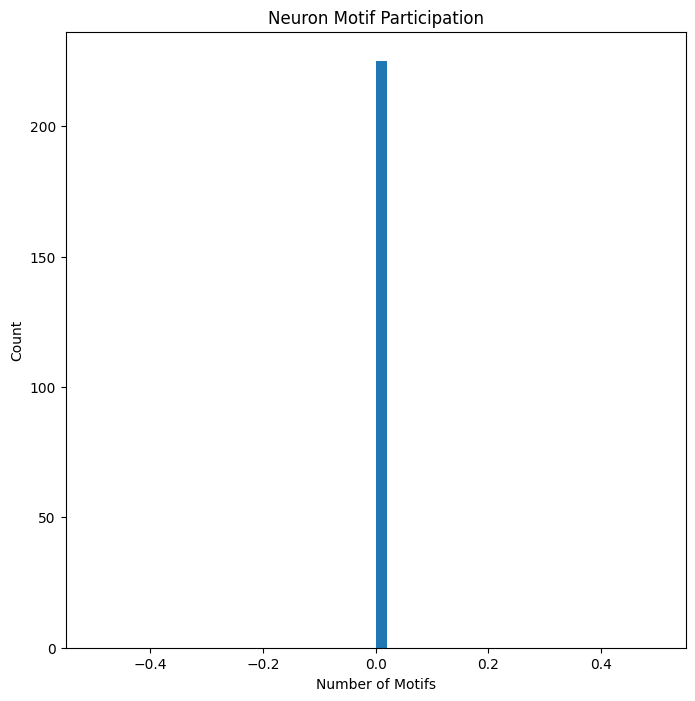

In [52]:
# === Cell: Motif Participation Profiles ===
import pickle

# Load motif data
with open("long_metrics/motifs3.pkl", "rb") as f:
    motifs3 = pickle.load(f)
with open("long_metrics/motifs4.pkl", "rb") as f:
    motifs4 = pickle.load(f)

# Build participation matrix (node → motif count)
from collections import Counter, defaultdict

participation = defaultdict(int)
for motif in motifs3 + motifs4:
    for node in motif:
        participation[node] += 1

participation_vec = np.array([participation.get(node, 0) for node in nodes])

plt.hist(participation_vec, bins=50)
plt.title("Neuron Motif Participation")
plt.xlabel("Number of Motifs")
plt.ylabel("Count")
plt.show()


In [55]:
# --- Cell A: recover context + imports ---
import os, pickle, numpy as np, pandas as pd, networkx as nx, matplotlib.pyplot as plt
from pathlib import Path

# Ensure filtered projection graph is available
if 'G_small' not in globals():
    if Path("neuron_projection_small.pkl").exists():
        with open("neuron_projection_small.pkl", "rb") as f:
            G_small = pickle.load(f)
    else:
        raise FileNotFoundError("neuron_projection_small.pkl not found, and G_small not in memory.")

# Ensure consolidated hypergraph summary is available
if 'summary_df' not in globals():
    if Path("hub_neuron_summary.csv").exists():
        summary_df = pd.read_csv("hub_neuron_summary.csv").set_index("Neuron")
    else:
        # fallback if not previously exported
        deg = dict(G_small.degree())
        summary_df = pd.DataFrame({"MotifCount": pd.Series(deg)})

print(f"G_small: {G_small.number_of_nodes()} nodes, {G_small.number_of_edges()} edges")


G_small: 225 nodes, 25019 edges


In [58]:
import pickle
import collections
import tqdm

def classify_motif(motif):
    """
    Fast approximate classification of motif structure.
    Handles multiple input formats:
      - list of nodes
      - list of edges
      - dict with 'nodes' and 'edges'
      - tuple (nodes, edges)
    """
    # Normalize format
    if isinstance(motif, dict):
        nodes = motif.get("nodes", [])
        edges = motif.get("edges", [])
    elif isinstance(motif, tuple) and len(motif) == 2:
        nodes, edges = motif
    elif all(isinstance(x, tuple) and len(x) == 2 for x in motif):  
        # edge list only
        edges = motif
        nodes = set([u for u,v in edges] + [v for u,v in edges])
    else:  
        # assume it's a node list only
        nodes = motif
        edges = []

    n = len(nodes)
    e = len(edges)

    degs = collections.Counter([u for u,v in edges] + [v for u,v in edges])
    dseq = sorted(degs.values(), reverse=True)

    # Classify
    if n == 3 and e == 3:
        return "triangle"
    elif n == 3 and e == 2:
        return "chain"
    elif n == 4 and e == 6:
        return "4-clique"
    elif n == 4 and e == 4:
        if dseq == [2,2,2,2]:
            return "4-cycle"
        else:
            return "other-4"
    elif max(dseq, default=0) == n-1:
        return "star"
    else:
        return f"other-{n}"

# === Load and classify motifs ===
motif_files = [
    "long_metrics/motifs3.pkl",
    "long_metrics/motifs4.pkl"
]

spectra = collections.Counter()

for fpath in motif_files:
    print(f"🔍 Loading {fpath} ...")
    with open(fpath, "rb") as f:
        motifs = pickle.load(f)
    print(f"  → {len(motifs)} motifs")

    for motif in tqdm.tqdm(motifs, desc=f"Classifying {fpath}"):
        spectra[classify_motif(motif)] += 1

print("\n✅ Motif spectra computed")
for k,v in spectra.most_common():
    print(f"{k:12s} : {v}")


🔍 Loading long_metrics/motifs3.pkl ...
  → 563600 motifs


Classifying long_metrics/motifs3.pkl: 100%|██████████| 563600/563600 [00:01<00:00, 434850.94it/s]


🔍 Loading long_metrics/motifs4.pkl ...


: 

In [ ]:
# --- Cell C: triangle participation vs hypergraph motif count ---
tri_per_node = nx.triangles(G_small)  # dict neuron -> #triangles in G_small

tri_df = pd.DataFrame.from_dict(tri_per_node, orient="index", columns=["Triangles"])
tri_df.index.name = "Neuron"
if "MotifCount" in summary_df.columns:
    tri_df = tri_df.join(summary_df[["MotifCount"]], how="left")

tri_df = tri_df.sort_values("Triangles", ascending=False)
tri_df.to_csv("long_metrics/triangle_participation.csv")

print("Top 15 triangle-rich neurons:")
display(tri_df.head(15))

plt.figure(figsize=(6,5))
plt.scatter(tri_df["MotifCount"], tri_df["Triangles"], s=12, alpha=0.7)
plt.xlabel("MotifCount (from hypergraph)")
plt.ylabel("Triangle participation (G_small)")
plt.title("Hypergraph motifs vs triangles in G_small")
plt.tight_layout(); plt.show()


In [ ]:
# --- Cell D: communities on G_small + embedding separability ---
# detect communities
try:
    import community as community_louvain
    part_small = community_louvain.best_partition(G_small, random_state=42)
except Exception:
    comms = nx.algorithms.community.greedy_modularity_communities(G_small)
    part_small = {n:i for i, c in enumerate(comms) for n in c}

nx.set_node_attributes(G_small, part_small, "community")

# (Re)compute a small Node2Vec so ordering is guaranteed and saved
from node2vec import Node2Vec
ordered_nodes = list(G_small.nodes())
n2v = Node2Vec(G_small, dimensions=32, walk_length=20, num_walks=50, workers=2, quiet=True)
w2v = n2v.fit(window=5, min_count=1)

X = np.vstack([w2v.wv[str(n)] for n in ordered_nodes]).astype(np.float32)
labels = np.array([part_small[n] for n in ordered_nodes], dtype=int)

# visualize
from sklearn.manifold import TSNE
XY = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(X)

plt.figure(figsize=(8,6))
plt.scatter(XY[:,0], XY[:,1], c=labels, cmap="tab10", s=12)
plt.title("Node2Vec embeddings (G_small) colored by community")
plt.tight_layout(); plt.show()

# silhouette score (only if >1 cluster and non-trivial)
from sklearn.metrics import silhouette_score
if len(set(labels)) > 1 and all(np.bincount(labels) > 1):
    sil = silhouette_score(X, labels)
    print(f"Silhouette score (embeddings vs communities): {sil:.3f}")
else:
    print("Silhouette score skipped (single or tiny community).")


In [ ]:
# --- Cell E: consolidated metrics for each neuron in G_small ---
deg_small = dict(G_small.degree())
comm_small = nx.get_node_attributes(G_small, "community")
tri_small = nx.triangles(G_small)

consolidated = pd.DataFrame({
    "Neuron": list(G_small.nodes()),
    "GraphDegree": [deg_small[n] for n in G_small.nodes()],
    "Triangles": [tri_small[n] for n in G_small.nodes()],
    "CommunitySmall": [comm_small.get(n, np.nan) for n in G_small.nodes()],
}).set_index("Neuron")

if "MotifCount" in summary_df.columns:
    consolidated = consolidated.join(summary_df[["MotifCount","Community","Type"]], how="left")

os.makedirs("long_metrics", exist_ok=True)
consolidated.to_csv("long_metrics/neuron_consolidated_metrics.csv")
print("✅ Saved → long_metrics/neuron_consolidated_metrics.csv")
display(consolidated.sort_values(["Triangles","GraphDegree"], ascending=False).head(20))
